# Least squares
In this File the algorithms are tested on the Least squares problem: 

$$min_{x \in \mathbb R^n} f(x)$$

Where $f(x) = \frac{1}{m} \lVert Ax -b \rVert^2$, $A \in \mathbb R^{m \times n}$, $b \in \mathbb R^m$.

Note that the gradient of f is given by $\nabla f(x) = \frac{2}{m} A^T (Ax - b)$, which is Lipschitz continous with Lipschitz constant $L = \frac{2}{m} \lVert A^T A \rVert = \frac{2}{m} \text{max}_{i = 1, \dots n} \lambda_i$ ($\lambda_i$ are the eigenvalues of $A^TA$)

The matrices $A$ that are used are bodyfat ($m=252$, $n=14$) and cadata ($m=20640$, $n=8$) from LIBSVM as well as two matrices with random entries in $[0,1)$: Random small ($m=1000$, $n=4000$), random large ($m=4000$, $n=8000$)

The data $b$ that is used is defined through a random (optimal) vector $x^*$ with entries in $[0,1)$ as $b = Ax^*$. Note that this implies that the optimal value of the minimization problem is 0.

In [1]:
import numpy as np
from AdaAGM import AdaAGM
from Algorithms import constant_gradient, Nesterov_gradient, AdaNAG_G
import matplotlib.pyplot as plt
import numpy.linalg as la
import time

## Setting up 4 model problems

In [2]:
import os
from sklearn.datasets import load_svmlight_file
#loading bodyfat data
data_path = os.getcwd() + '\\datasets\\bodyfat'
data_matrix, data_vector = load_svmlight_file(data_path)

A_bodyfat = data_matrix.toarray()

#loading cadata data
data_path = os.getcwd() + '\\datasets\\cadata'
data_matrix, data_vector = load_svmlight_file(data_path)

A_cadata = data_matrix.toarray()

#creating random small data
A_random_small = np.random.rand(1000, 4000)

#creating random small data
A_random_large = np.random.rand(4000, 8000)

In [3]:
matrices = [("bodyfat", A_bodyfat), ("cadata", A_cadata), ("random small", A_random_small), ("random large", A_random_large)]

iteration_list = [20000, 100000, 6000, 10000]

## Setting up AdaAGM
Corollary 5.5 gives the following constants:
$\gamma = \frac{1}{2}, \beta = 1$, $m \in (0,1)$, $t_0 = 2$ and $\omega = \delta = \frac{1}{2}$.

Also the initial stepsize needs to satisfy the follwing: $s_0 \geq \frac{1}{12 L}$, which is guaranteed during the calculation of sequences.

I will choose $m = 0.1$, $m = 0.5$ and $m=0.9$

Note that Corollary 5.5 applies to functions $f$ that are strongly convex. The objective function of the least squares problem is strongly convex if and only if the matrix $A$ is full rank, which means in the problems below it might not be satisfied. However, also the choices above also satisfy the conditions for the convex case in the paper, so even if $A$ is not full rank, a convergence of $\mathcal{O}(\frac{1}{k^2})$ is guaranteed.

In [4]:
t_5_0 = 2
omega_5 = 1/2
delta_5 = 1/2
beta_5 = 1
gamma_5 = 1/2
m_1 = 0.1
m_5 = 0.5
m_9 = 0.9

Corollary 5.6 gives the following constants: $\gamma = 1$, $\beta = \frac{1}{3}$, $m \in (0,1)$, $t_0 = 3$ and $\omega = \delta = \frac{1}{2}$

Also the initial stepsize needs to satisfy the follwing: $s_0 \geq \frac{1}{16 L}$, which is guaranteed during the calculation of sequences.

I will choose $m = 0.1$, $m = 0.5$ and $m=0.9$

In [5]:
t_6_0 = 3
omega_6 = 0.5
delta_6 = 0.5
beta_6 = 1/3
gamma_6 = 1

## Setting up AdaNAG_G$_{12}$ and AdaNAG_G$^{1 / 2}$
### Choices of constants and sequences
AdaNAG_G$_{12}$: Corollary 7 gives the follwing: $\tau_k = \frac{(k+2) + 12}{12}$, $\alpha_k = \frac{1}{2} \frac{(\tau_{k+1} - 1)^2}{\tau_k^2}$ and $B_0 = \alpha_0^2\tau_0^2(\frac{(\tau_0 - 1)^2}{\alpha_{-1}\tau_{-1}^2} -1)$

In [6]:
tau_12 = lambda k: ((k+2) + 12)/12
alpha_12 = lambda k: 1/2 * (tau_12(k+1) - 1)**2/(tau_12(k)**2)
tau_12_m1 = tau_12(-1)
tau_12_0 = tau_12(0)
tau_12_1 = tau_12(1)
alpha_12_m1 = alpha_12(-1)
alpha_12_0 = alpha_12(0)
B_12_0 = alpha_12_0**2 * tau_12_0**2 *((tau_12_0-1)**2/(alpha_12_m1*tau_12_m1**2) - 1)

AdaNAG_G$^{1 / 2}$: Corollary 8 gives the following: $\tau_k = 2 \sqrt{k + 3}$, $\alpha_k = \frac{1}{2}$ and $B_0 = \alpha_0^2\tau_0^2(\frac{(\tau_0 - 1)^2}{\alpha_{-1}\tau_{-1}^2} -1)$

In [7]:
tau_half = lambda k: 2*np.sqrt(k + 3)
alpha_half = lambda k: 1/2
tau_half_m1 = tau_half(-1)
tau_half_0 = tau_half(0)
tau_half_1 = tau_half(1)
alpha_half_m1 = alpha_half(-1)
alpha_half_0 = alpha_half(0)
B_half_0 = alpha_half_0**2 * tau_half_0**2 * ((tau_half_0 - 1)**2 /(alpha_half_m1 * tau_half_m1**2) - 1)

### Initial stepsize
The paper defines the initial stepsize in the follwoing way: $s_0 = \frac{A_0}{\alpha_0\tau_0} \frac{r}{\alpha_1} \frac{1}{L_0}$

Here $A_0$, $\alpha_0$, $\tau_0$ and $\alpha_1$ are given by the Algorithm.

$L_0$ is defined as: $L_0 = \frac{\lVert \nabla f(x_0) - \nabla f(\tilde{x}_0) \rVert}{\lVert x_0 - \tilde{x}_0 \rVert}$ with $x_0$ the starting value and $\tilde{x}_0 = x_0 + u$, where the entries of u are random in $[0,1)$.

The Proof of Corollary 7 (AdaNAG_G$_{12}$ yields a choice of $r = \alpha_1 r_0^L$ with $r_k^L = (\frac{A_k}{B_k} + \frac{B_{k+1} + \alpha_{k+1}^2 \tau_{k+1}^2}{A_k})^{-1}$

For Corollary 8 (i.e. AdaNAG_G$^{1/2}$): $r = \frac{1}{10}$

In [8]:
def initial_stepize_AdaNAG_G(tau, alpha, B_0, L_0, half_False_12_True):
    """
    Calculate the initial stepsize of AdaNAG_G_12 or AdaNAG_G_half given in the paper
    """
    tau_m1 = tau(-1)
    tau_0 = tau(0)
    tau_1 = tau(1)
    
    alpha_0 = alpha(0)
    alpha_1 = alpha(1)
    A_0 = alpha_1*tau_1*(tau_1 - 1)
    B_1 = alpha_1**2 * tau_1**2 * ((tau_1)**2/(alpha_0 * tau_0**2) - 1)
    
    if half_False_12_True:
        r_0_L = 1/(A_0/B_0 + (B_1 + alpha_1**2 * tau_1**2)/A_0)
        r = alpha_1*r_0_L
    else:
        r = 1/10

    return A_0/(alpha_0*tau_0) * r/alpha_1 * 1/L_0

## Calculation of sequences

In [9]:
methods = [
    ("const_gradient", lambda: constant_gradient(function, gradient, x_0, s_0_const, iterations)),
    ("Nesterov", lambda: Nesterov_gradient(function, gradient, x_0, s_0_const, iterations)),
    ("AdaNAG_G_12", lambda: AdaNAG_G(function, gradient, x_0, s_0_AdaNAG_G_12, iterations, tau_12, alpha_12, B_12_0)),
    ("AdaNAG_G_half", lambda: AdaNAG_G(function, gradient, x_0, s_0_AdaNAG_G_half, iterations, tau_half, alpha_half, B_half_0)),
    
    ("AdaAGM_5_m01", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_5, t_5_0, m_1, s_0_AdaAGM_5, omega_5, delta_5, beta_5, iterations)),
    ("AdaAGM_5_m05", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_5, t_5_0, m_5, s_0_AdaAGM_5, omega_5, delta_5, beta_5, iterations)),
    ("AdaAGM_5_m09", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_5, t_5_0, m_9, s_0_AdaAGM_5, omega_5, delta_5, beta_5, iterations)),

    ("AdaAGM_6_m01", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_6, t_6_0, m_1, s_0_AdaAGM_6, omega_6, delta_6, beta_6, iterations)),
    ("AdaAGM_6_m05", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_6, t_6_0, m_5, s_0_AdaAGM_6, omega_6, delta_6, beta_6, iterations)),
    ("AdaAGM_6_m09", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_6, t_6_0, m_9, s_0_AdaAGM_6, omega_6, delta_6, beta_6, iterations)),
]


In [12]:
function_values = []
gradient_norms = []
calculation_times = []
minimum = []

for n, (matrix_name, A) in enumerate(matrices):
    iterations = iteration_list[n]

    num_rows, num_cols = A.shape

    x_optimal = np.random.rand(num_cols)
    b = A @ x_optimal

    function = lambda x: 1/num_rows * np.linalg.norm(A @ x - b)**2
    gradient = lambda x: 2/num_rows * A.T @ (A @ x - b)

    x_0 = np.zeros(num_cols)
    y_0 = x_0
    
    #Lipschitz constant of problem:
    L = 2/num_rows * np.max(la.eigvalsh(A.T @ A))
    
    #choice of initial stepsices
    #Nesterov and constant gradient require s_0 < 1/L
    s_0_const = 1 / L
    x_0_tilde = np.random.rand(num_cols)
    L_0 = la.norm(gradient(x_0) - gradient(x_0_tilde)) / la.norm(x_0 - x_0_tilde)

    s_0_AdaNAG_G_12 = initial_stepize_AdaNAG_G(tau_12, alpha_12, B_12_0, L_0, True)
    s_0_AdaNAG_G_half = initial_stepize_AdaNAG_G(tau_half, alpha_half, B_half_0, L_0, False)
    s_0_AdaAGM_5 = 1 / (12 * L)
    s_0_AdaAGM_6 = 1 / (16 * L)

    function_values.append([])
    gradient_norms.append([])

    for index, (method_name, method) in enumerate(methods):
        tic = time.time()
        sol = method()
        toc = time.time()
        print(f"{method_name} Done")
        
        #to save memory, save Iterates for every method seperately
        np.savez_compressed(f"Testing results/Least squares/Iterates/{matrix_name}/{method_name}.npz", iterates=np.array(sol[0]).astype(np.float32))
        gradient_norms[n].append(sol[1])
        calculation_times.append(toc - tic)
        
        #Constant gradient and Nesterov method don't need evaluations of objective function
        if method_name == "const_gradient" or method_name == "Nesterov":
            function_values[n].append([function(iterate) for iterate in sol[0]])
        else:
            function_values[n].append(sol[2])
            
    minimum.append(np.min(np.concatenate(function_values[n])))

const_gradient Done
Nesterov Done
AdaNAG_G_12 Done
AdaNAG_G_half Done
AdaAGM_5_m01 Done
AdaAGM_5_m05 Done
AdaAGM_5_m09 Done
AdaAGM_6_m01 Done
AdaAGM_6_m05 Done
AdaAGM_6_m09 Done
const_gradient Done
Nesterov Done
AdaNAG_G_12 Done
AdaNAG_G_half Done
AdaAGM_5_m01 Done
AdaAGM_5_m05 Done
AdaAGM_5_m09 Done
AdaAGM_6_m01 Done
AdaAGM_6_m05 Done
AdaAGM_6_m09 Done
const_gradient Done
Nesterov Done
AdaNAG_G_12 Done
AdaNAG_G_half Done
AdaAGM_5_m01 Done
AdaAGM_5_m05 Done
AdaAGM_5_m09 Done
AdaAGM_6_m01 Done
AdaAGM_6_m05 Done
AdaAGM_6_m09 Done
const_gradient Done
Nesterov Done
AdaNAG_G_12 Done
AdaNAG_G_half Done
AdaAGM_5_m01 Done
AdaAGM_5_m05 Done
AdaAGM_5_m09 Done
AdaAGM_6_m01 Done
AdaAGM_6_m05 Done
AdaAGM_6_m09 Done


In [14]:
np.save("Testing results/Least squares/function_values_least_squares.npy", function_values, allow_pickle=True)
np.save("Testing results/Least squares/gradient_norms_least_squares.npy", gradient_norms, allow_pickle=True)
np.save("Testing results/Least squares/calculation_times_least_squares.npy", calculation_times, allow_pickle=True)

C:\WinPython\WPy64-31050\python-3.10.5.amd64\lib\site-packages\numpy\lib\npyio.py:518: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


## Plots of function values

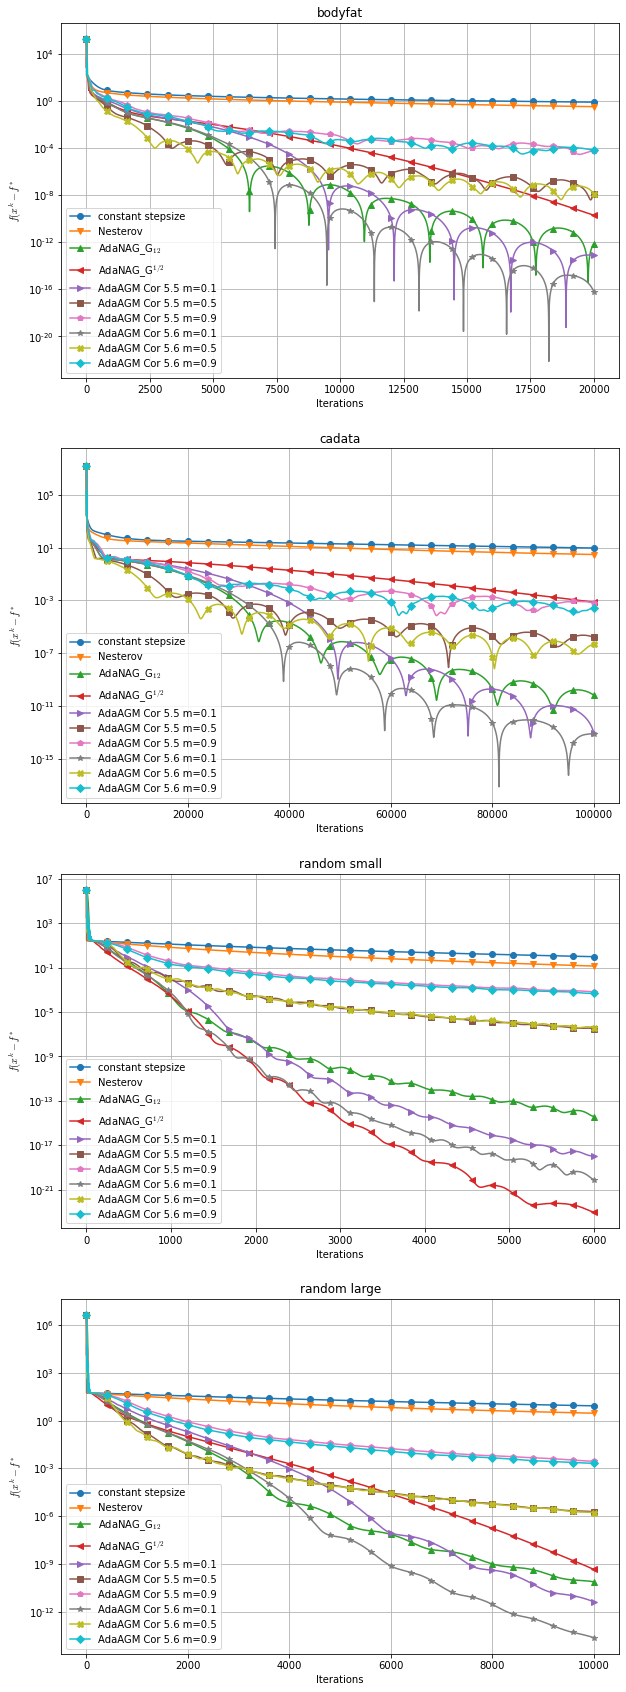

In [16]:
plt.rcParams["mathtext.fontset"] = "cm"
fig, ax = plt.subplots(4, figsize=(10,30))
labels = ['constant stepsize', 'Nesterov', 'AdaNAG_G$_{12}$', 'AdaNAG_G$^{1/2}$', 'AdaAGM Cor 5.5 m=0.1', 'AdaAGM Cor 5.5 m=0.5', 'AdaAGM Cor 5.5 m=0.9', 'AdaAGM Cor 5.6 m=0.1', 'AdaAGM Cor 5.6 m=0.5', 'AdaAGM Cor 5.6 m=0.9']
titles = ['bodyfat', 'cadata', 'random small', 'random large']
markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'X', 'D'] 
mark_every = [800, 4000, 240, 400]
for k in range(4):
    for index, value_sequence in enumerate(function_values[k]):
        ax[k].plot(value_sequence, label=labels[index], marker = markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend()
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel(r'$f(x^{k} - f^{*}$')
    ax[k].grid()

## Plots of gradient norms

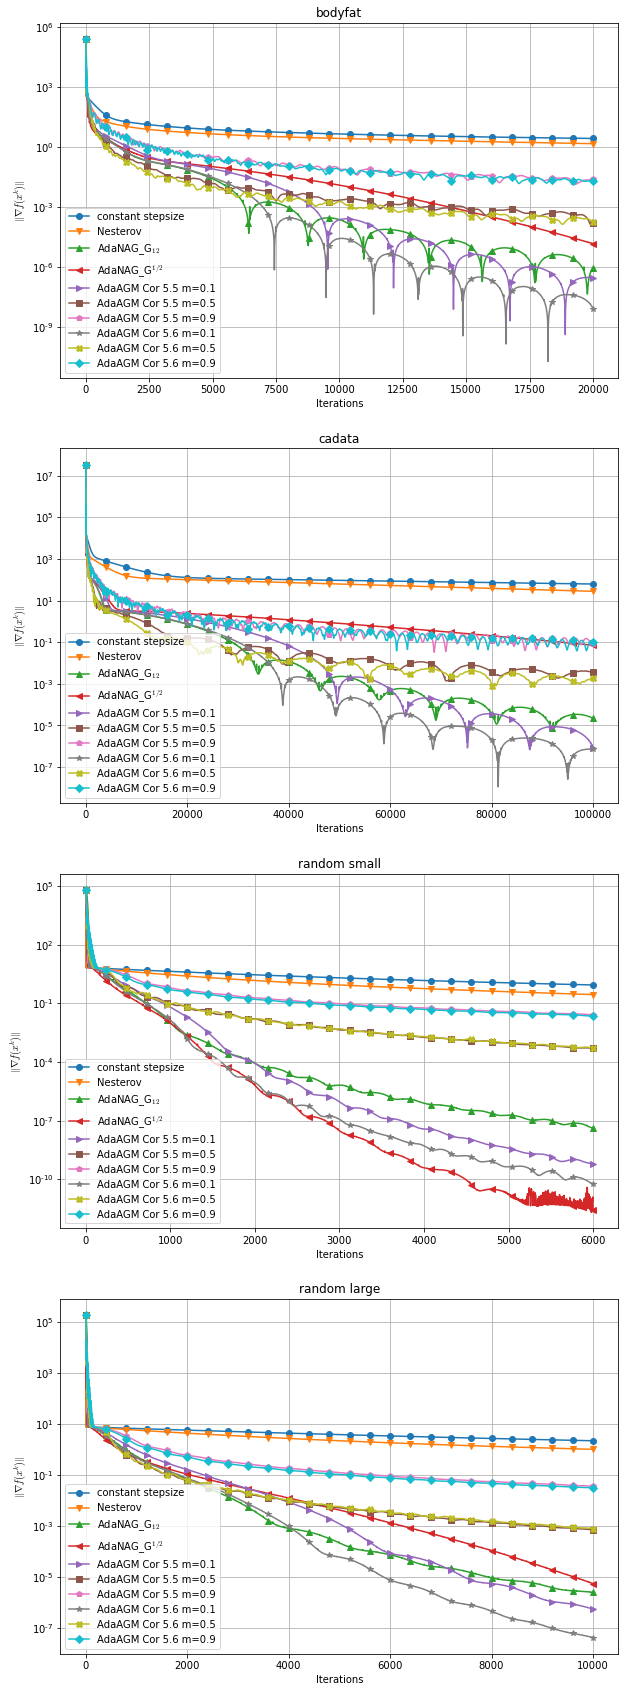

In [17]:
plt.rcParams["mathtext.fontset"] = "cm"
fig, ax = plt.subplots(4, figsize=(10,30))
labels = ['constant stepsize', 'Nesterov', 'AdaNAG_G$_{12}$', 'AdaNAG_G$^{1/2}$', 'AdaAGM Cor 5.5 m=0.1', 'AdaAGM Cor 5.5 m=0.5', 'AdaAGM Cor 5.5 m=0.9', 'AdaAGM Cor 5.6 m=0.1', 'AdaAGM Cor 5.6 m=0.5', 'AdaAGM Cor 5.6 m=0.9']
titles = ['bodyfat', 'cadata', 'random small', 'random large']
markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'X', 'D']
mark_every = [800, 4000, 240, 400]
for k in range(4):
    for index, gradient_sequence in enumerate(gradient_norms[k]):
        ax[k].plot(gradient_sequence, label=labels[index], marker = markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend(loc='lower left')
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel(r'$\Vert \nabla f(x^k) \Vert$')
    ax[k].grid()